In [68]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### Exploratory Data Analysis 

In [9]:
df = pd.read_excel(r"C:\Users\akash\Downloads\ppc_campaign_performance_data.xlsx")

In [11]:
df.head()

,Campaign_ID,Budget,Clicks,CTR,CPC,Conversions,CPA,Conversion_Rate,Duration,Platform,Content_Type,Target_Age,Target_Gender,Region,Revenue,Spend,ROAS,Date,Impressions
0,C3578,6390,401,0.0461,15.94,174,36.72,0.4339,20,Instagram,Carousel,35-44,Male,Europe,27840,6453.9,4.31,2025-01-19,8698
1,C6702,9870,1286,0.2860,7.67,821,12.02,0.6384,28,LinkedIn,Text,55+,Male,Africa,128076,10067.4,12.72,2025-01-22,4496
2,C9725,7700,1684,0.2122,4.57,1060,7.26,0.6295,15,Instagram,Video,35-44,Other,North America,193980,7623.0,25.45,2024-07-23,7935
3,C9472,8420,444,0.0961,18.96,308,27.34,0.6937,25,Google,Text,25-34,Male,North America,24024,8504.2,2.82,2024-04-20,4620
4,C7601,8470,1912,0.3652,4.43,1428,5.93,0.7469,9,Google,Text,25-34,Other,Europe,277032,8046.5,34.43,2024-08-07,5235


In [13]:
df.shape

(1000, 19)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Campaign_ID      1000 non-null   object 
 1   Budget           1000 non-null   int64  
 2   Clicks           1000 non-null   int64  
 3   CTR              1000 non-null   float64
 4   CPC              1000 non-null   float64
 5   Conversions      1000 non-null   int64  
 6   CPA              1000 non-null   float64
 7   Conversion_Rate  1000 non-null   float64
 8   Duration         1000 non-null   int64  
 9   Platform         1000 non-null   object 
 10  Content_Type     1000 non-null   object 
 11  Target_Age       1000 non-null   object 
 12  Target_Gender    1000 non-null   object 
 13  Region           1000 non-null   object 
 14  Revenue          1000 non-null   int64  
 15  Spend            1000 non-null   float64
 16  ROAS             1000 non-null   float64
 17  Date           

In [17]:
df['Date'] = pd.to_datetime(df['Date'])



In [154]:
df = df.assign(
    day_name=df['Date'].dt.day_name(),
    day_num=df['Date'].dt.dayofweek,
    month=df['Date'].dt.month,
    month_name=df['Date'].dt.month_name(),
    quarter=df['Date'].dt.quarter
)


In [39]:
num_cols = df.select_dtypes('number').columns.tolist()

cat_col = df.select_dtypes('object').columns.tolist()

In [60]:
num_cols

['Budget',
 'Clicks',
 'CTR',
 'CPC',
 'Conversions',
 'CPA',
 'Conversion_Rate',
 'Duration',
 'Revenue',
 'Spend',
 'ROAS',
 'Impressions']

In [64]:
cat_col

['Campaign_ID',
 'Platform',
 'Content_Type',
 'Target_Age',
 'Target_Gender',
 'Region']

In [43]:
df.describe()

,Budget,Clicks,CTR,CPC,Conversions,CPA,Conversion_Rate,Duration,Revenue,Spend,ROAS,Date,Impressions
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,5961.990000,1013.229000,0.258417,11.230730,505.67200,40.966170,0.508329,18.313000,59886.710000,5956.167800,11.689180,2024-08-04 19:39:21.600000,5497.177000
min,2030.000000,50.000000,0.006100,1.080000,10.00000,1.670000,0.009600,7.000000,598.000000,1928.500000,0.070000,2024-02-10 00:00:00,1000.000000
25%,4007.500000,514.250000,0.094275,3.707500,153.75000,7.157500,0.267000,12.000000,15111.250000,4031.475000,2.717500,2024-05-04 18:00:00,3262.750000
50%,5855.000000,996.500000,0.182150,5.755000,396.50000,14.245000,0.517150,18.000000,39378.000000,5843.650000,7.295000,2024-07-30 00:00:00,5410.000000
75%,7960.000000,1491.500000,0.306900,11.285000,772.25000,36.840000,0.751675,24.000000,86009.000000,7994.850000,15.552500,2024-10-31 00:00:00,7719.750000
max,9990.000000,1996.000000,1.785100,132.310000,1894.00000,733.080000,1.000000,30.000000,320788.000000,10468.500000,93.900000,2025-02-09 00:00:00,10000.000000
std,2326.091753,563.971223,0.262449,16.026811,424.76226,76.623075,0.284814,6.952796,60237.650065,2330.082996,13.173887,NaN,2576.010494


In [58]:
duplicates = df[df.duplicated()]
duplicates

,Campaign_ID,Budget,Clicks,CTR,CPC,Conversions,CPA,Conversion_Rate,Duration,Platform,Content_Type,Target_Age,Target_Gender,Region,Revenue,Spend,ROAS,Date,Impressions


<Figure size 2000x1000 with 0 Axes>

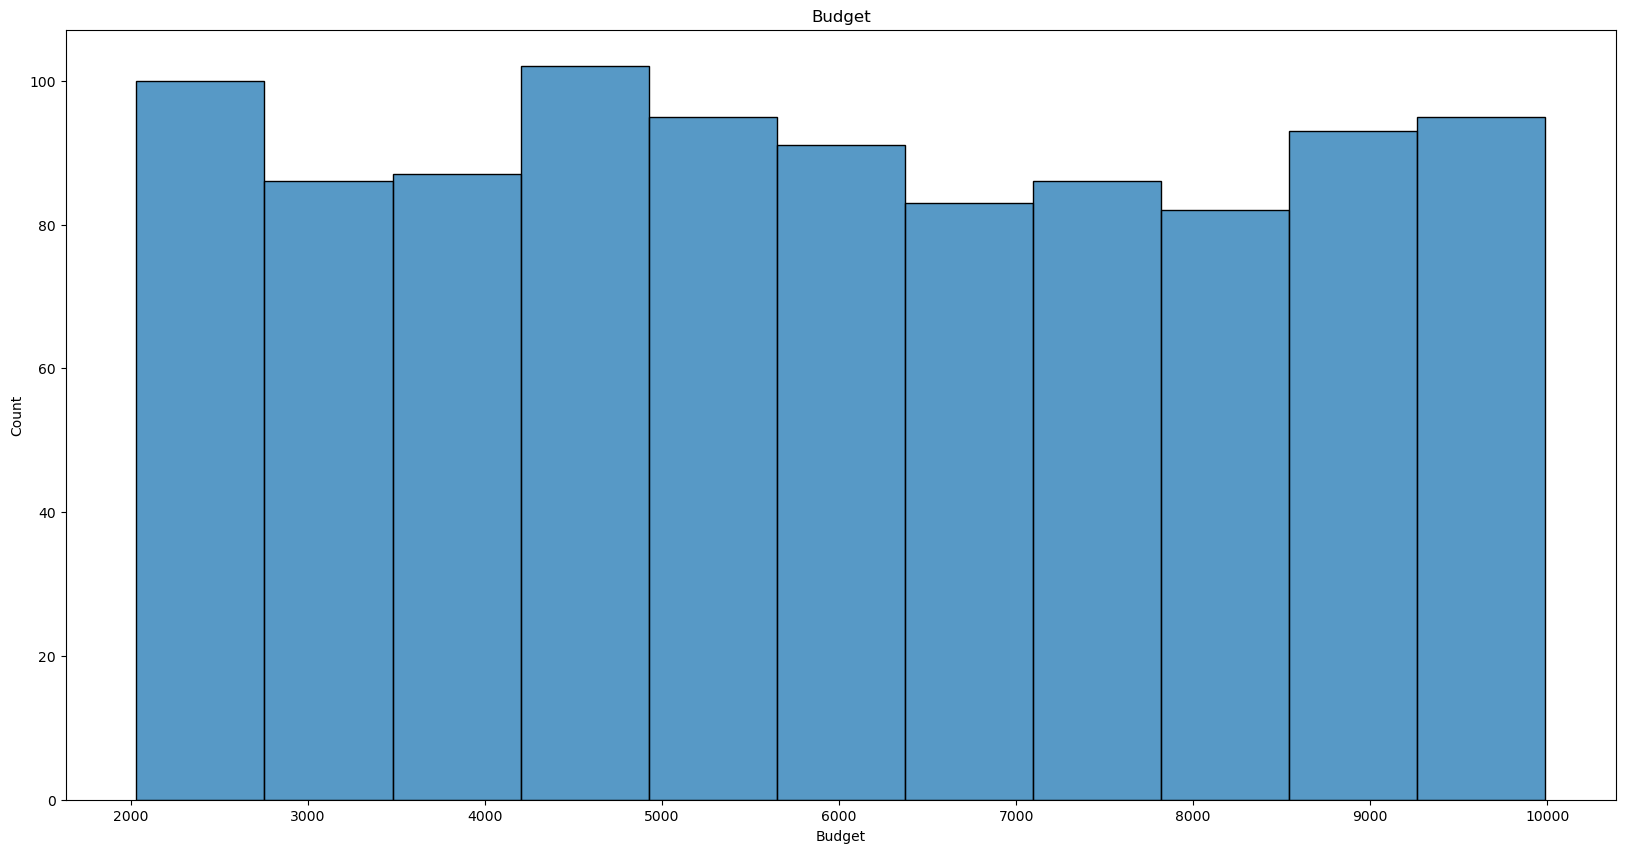

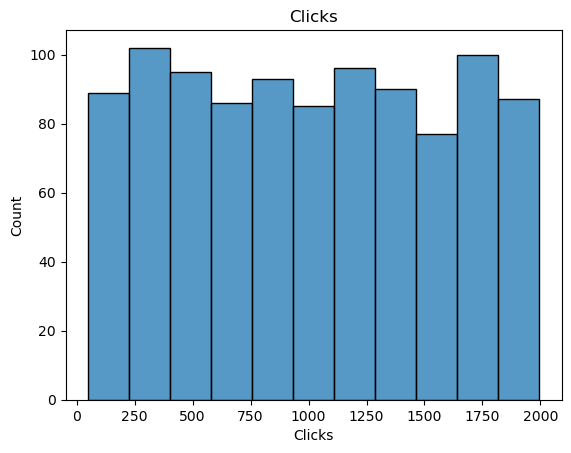

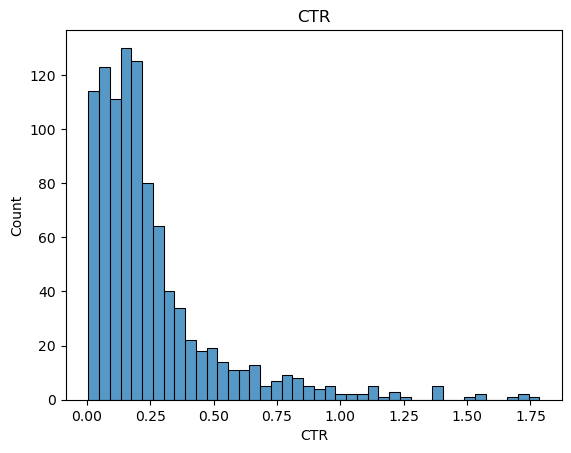

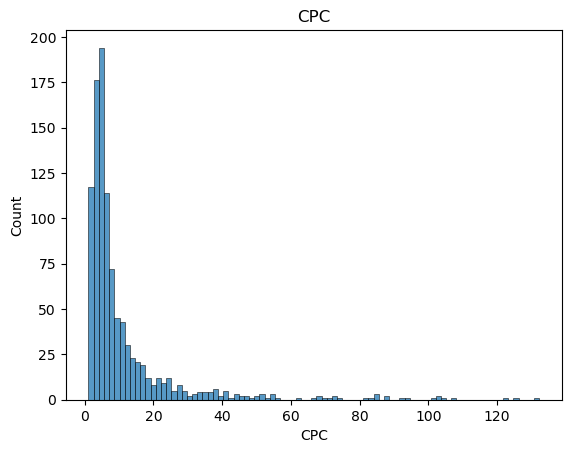

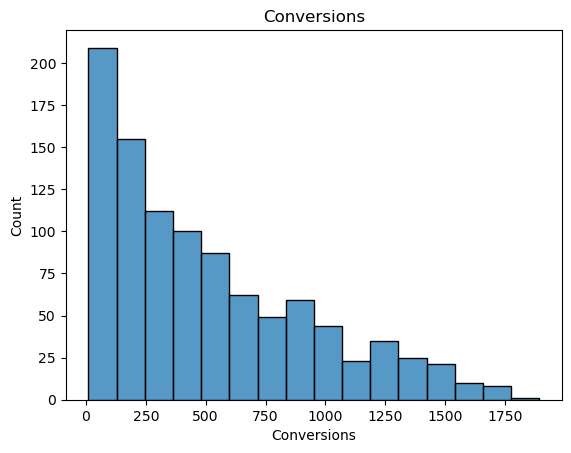

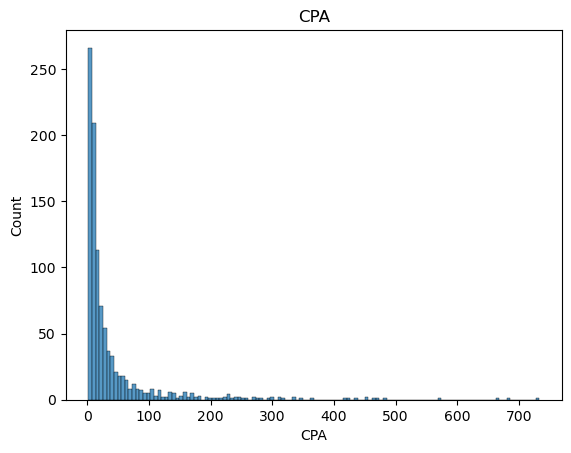

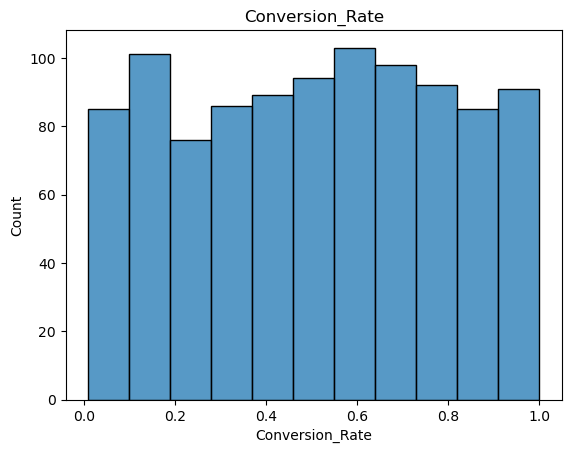

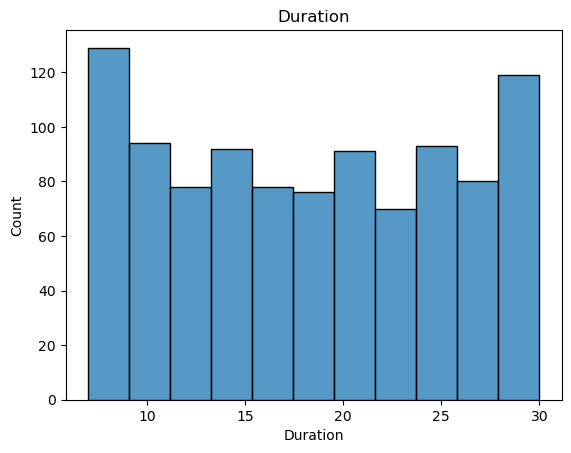

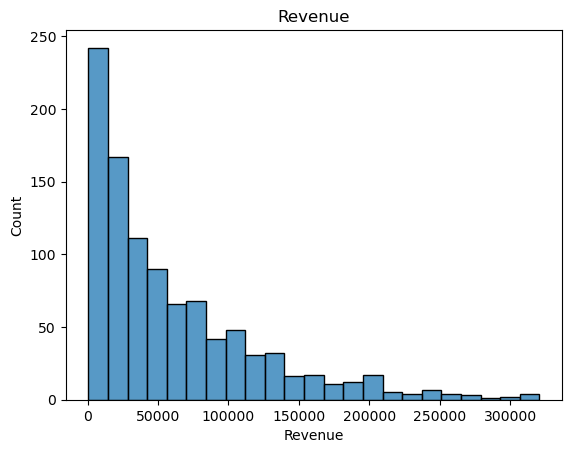

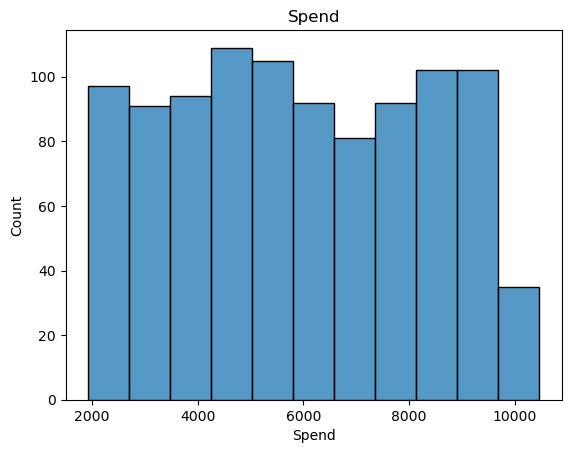

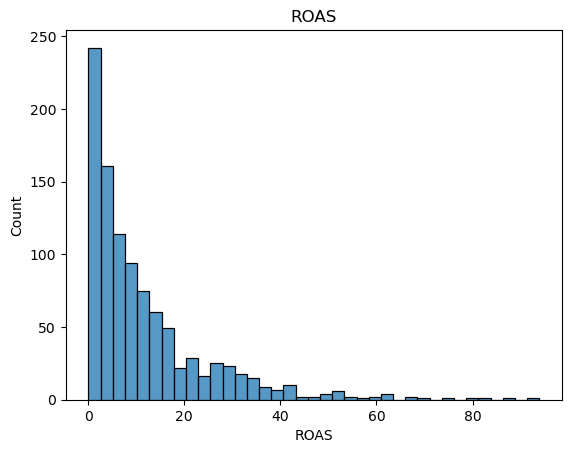

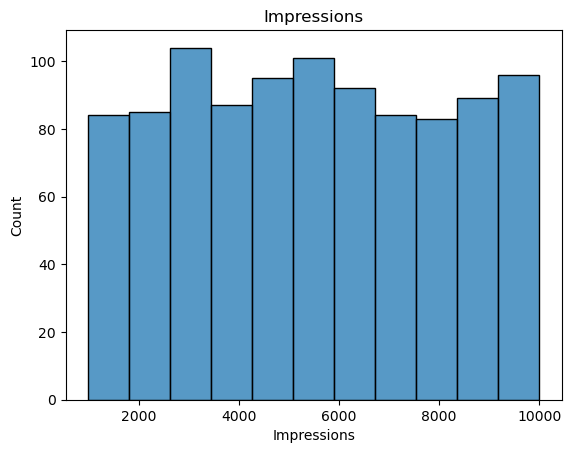

In [94]:
plt.figure(figsize = (20,10))

for i,var in enumerate(num_cols):
    sns.histplot(df[var])
    plt.title(var)
    plt.show()


In [115]:
def bivariate(var1, var2):
    sns.boxplot(x=var1, y=var2, data=df, hue = var1)
    
    
    plt.tight_layout()
    plt.show()

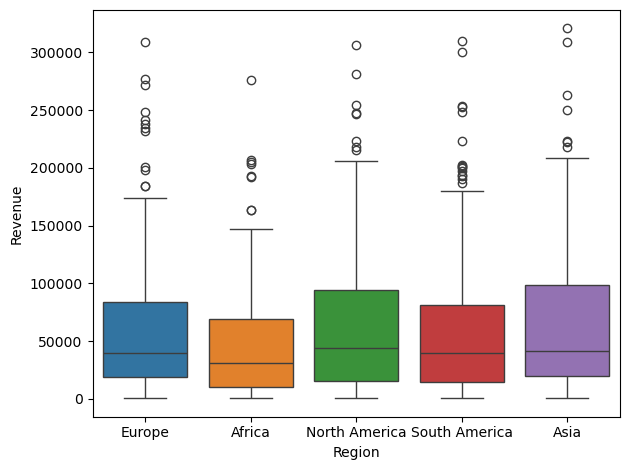

In [117]:
bivariate(df['Region'], df['Revenue'])

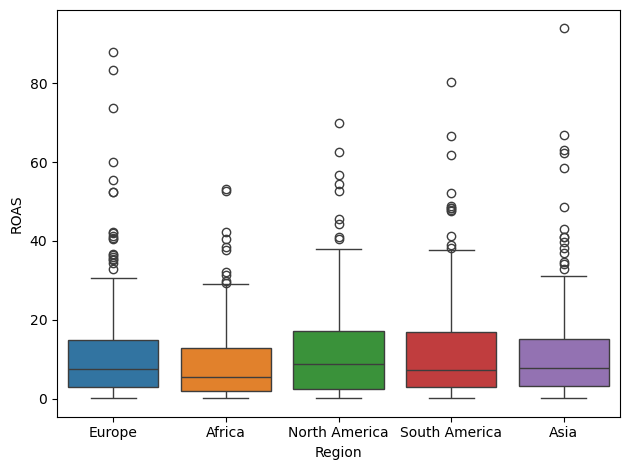

In [119]:
bivariate(df['Region'], df['ROAS'])

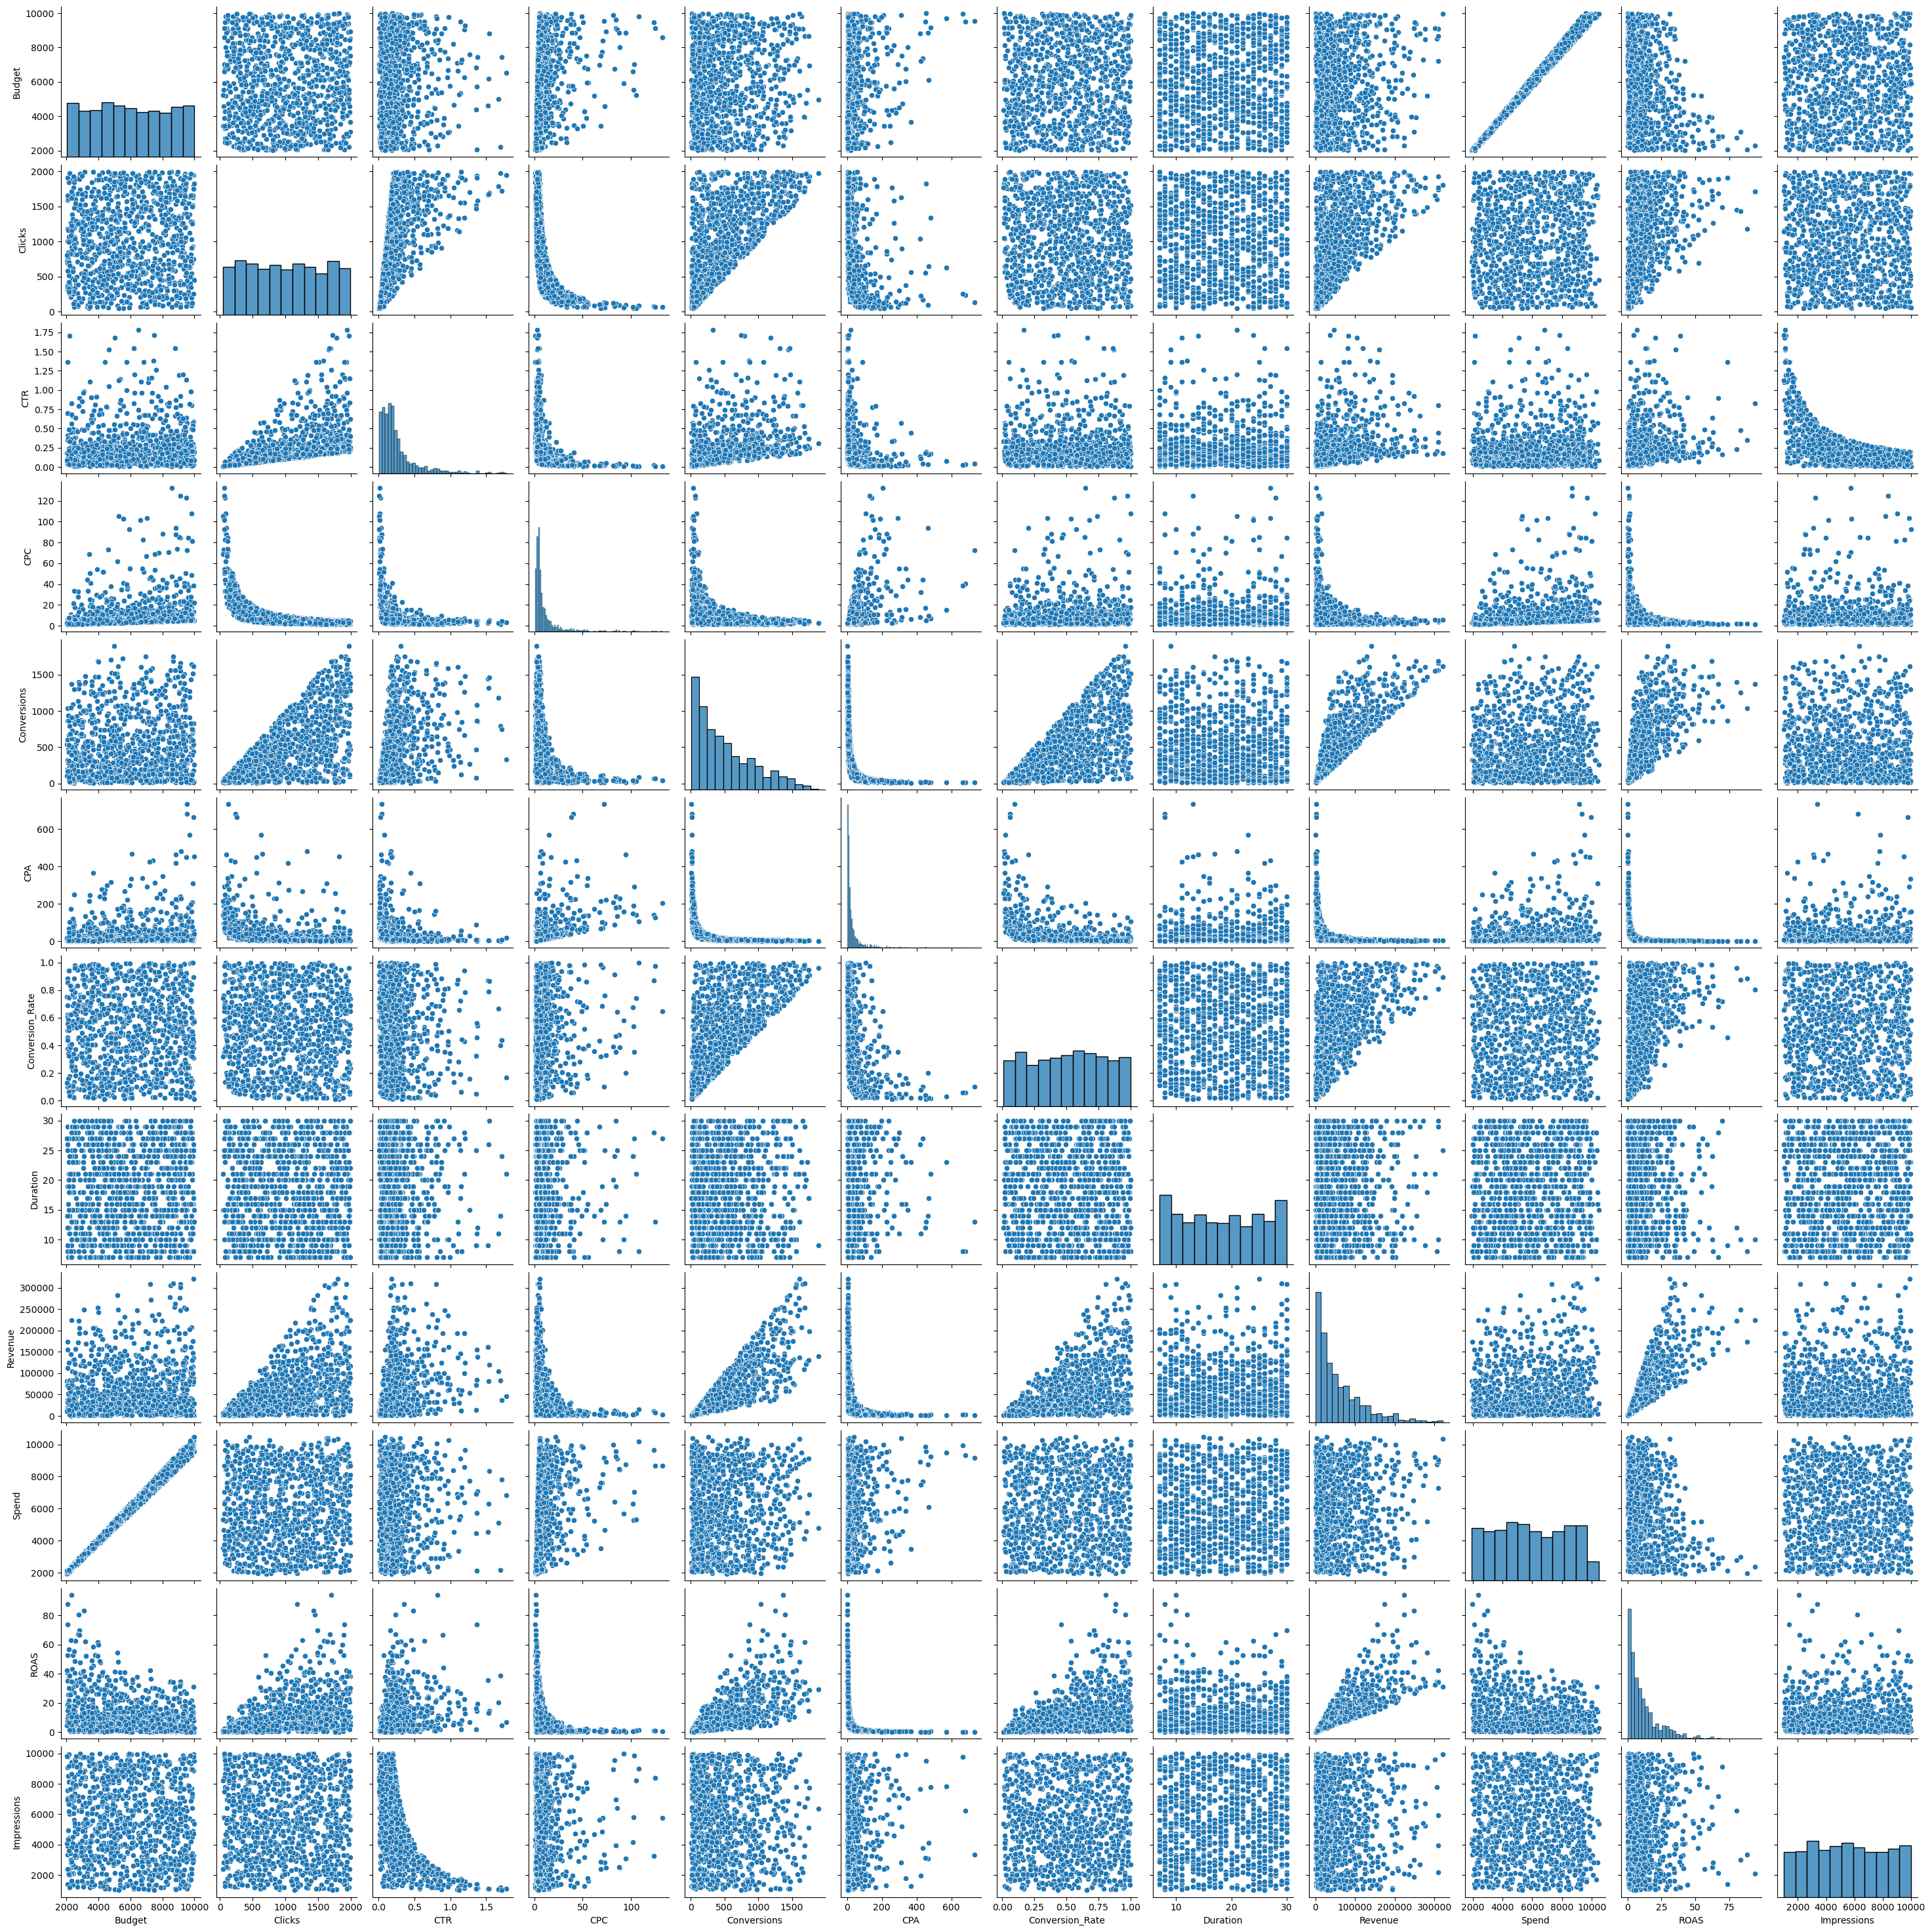

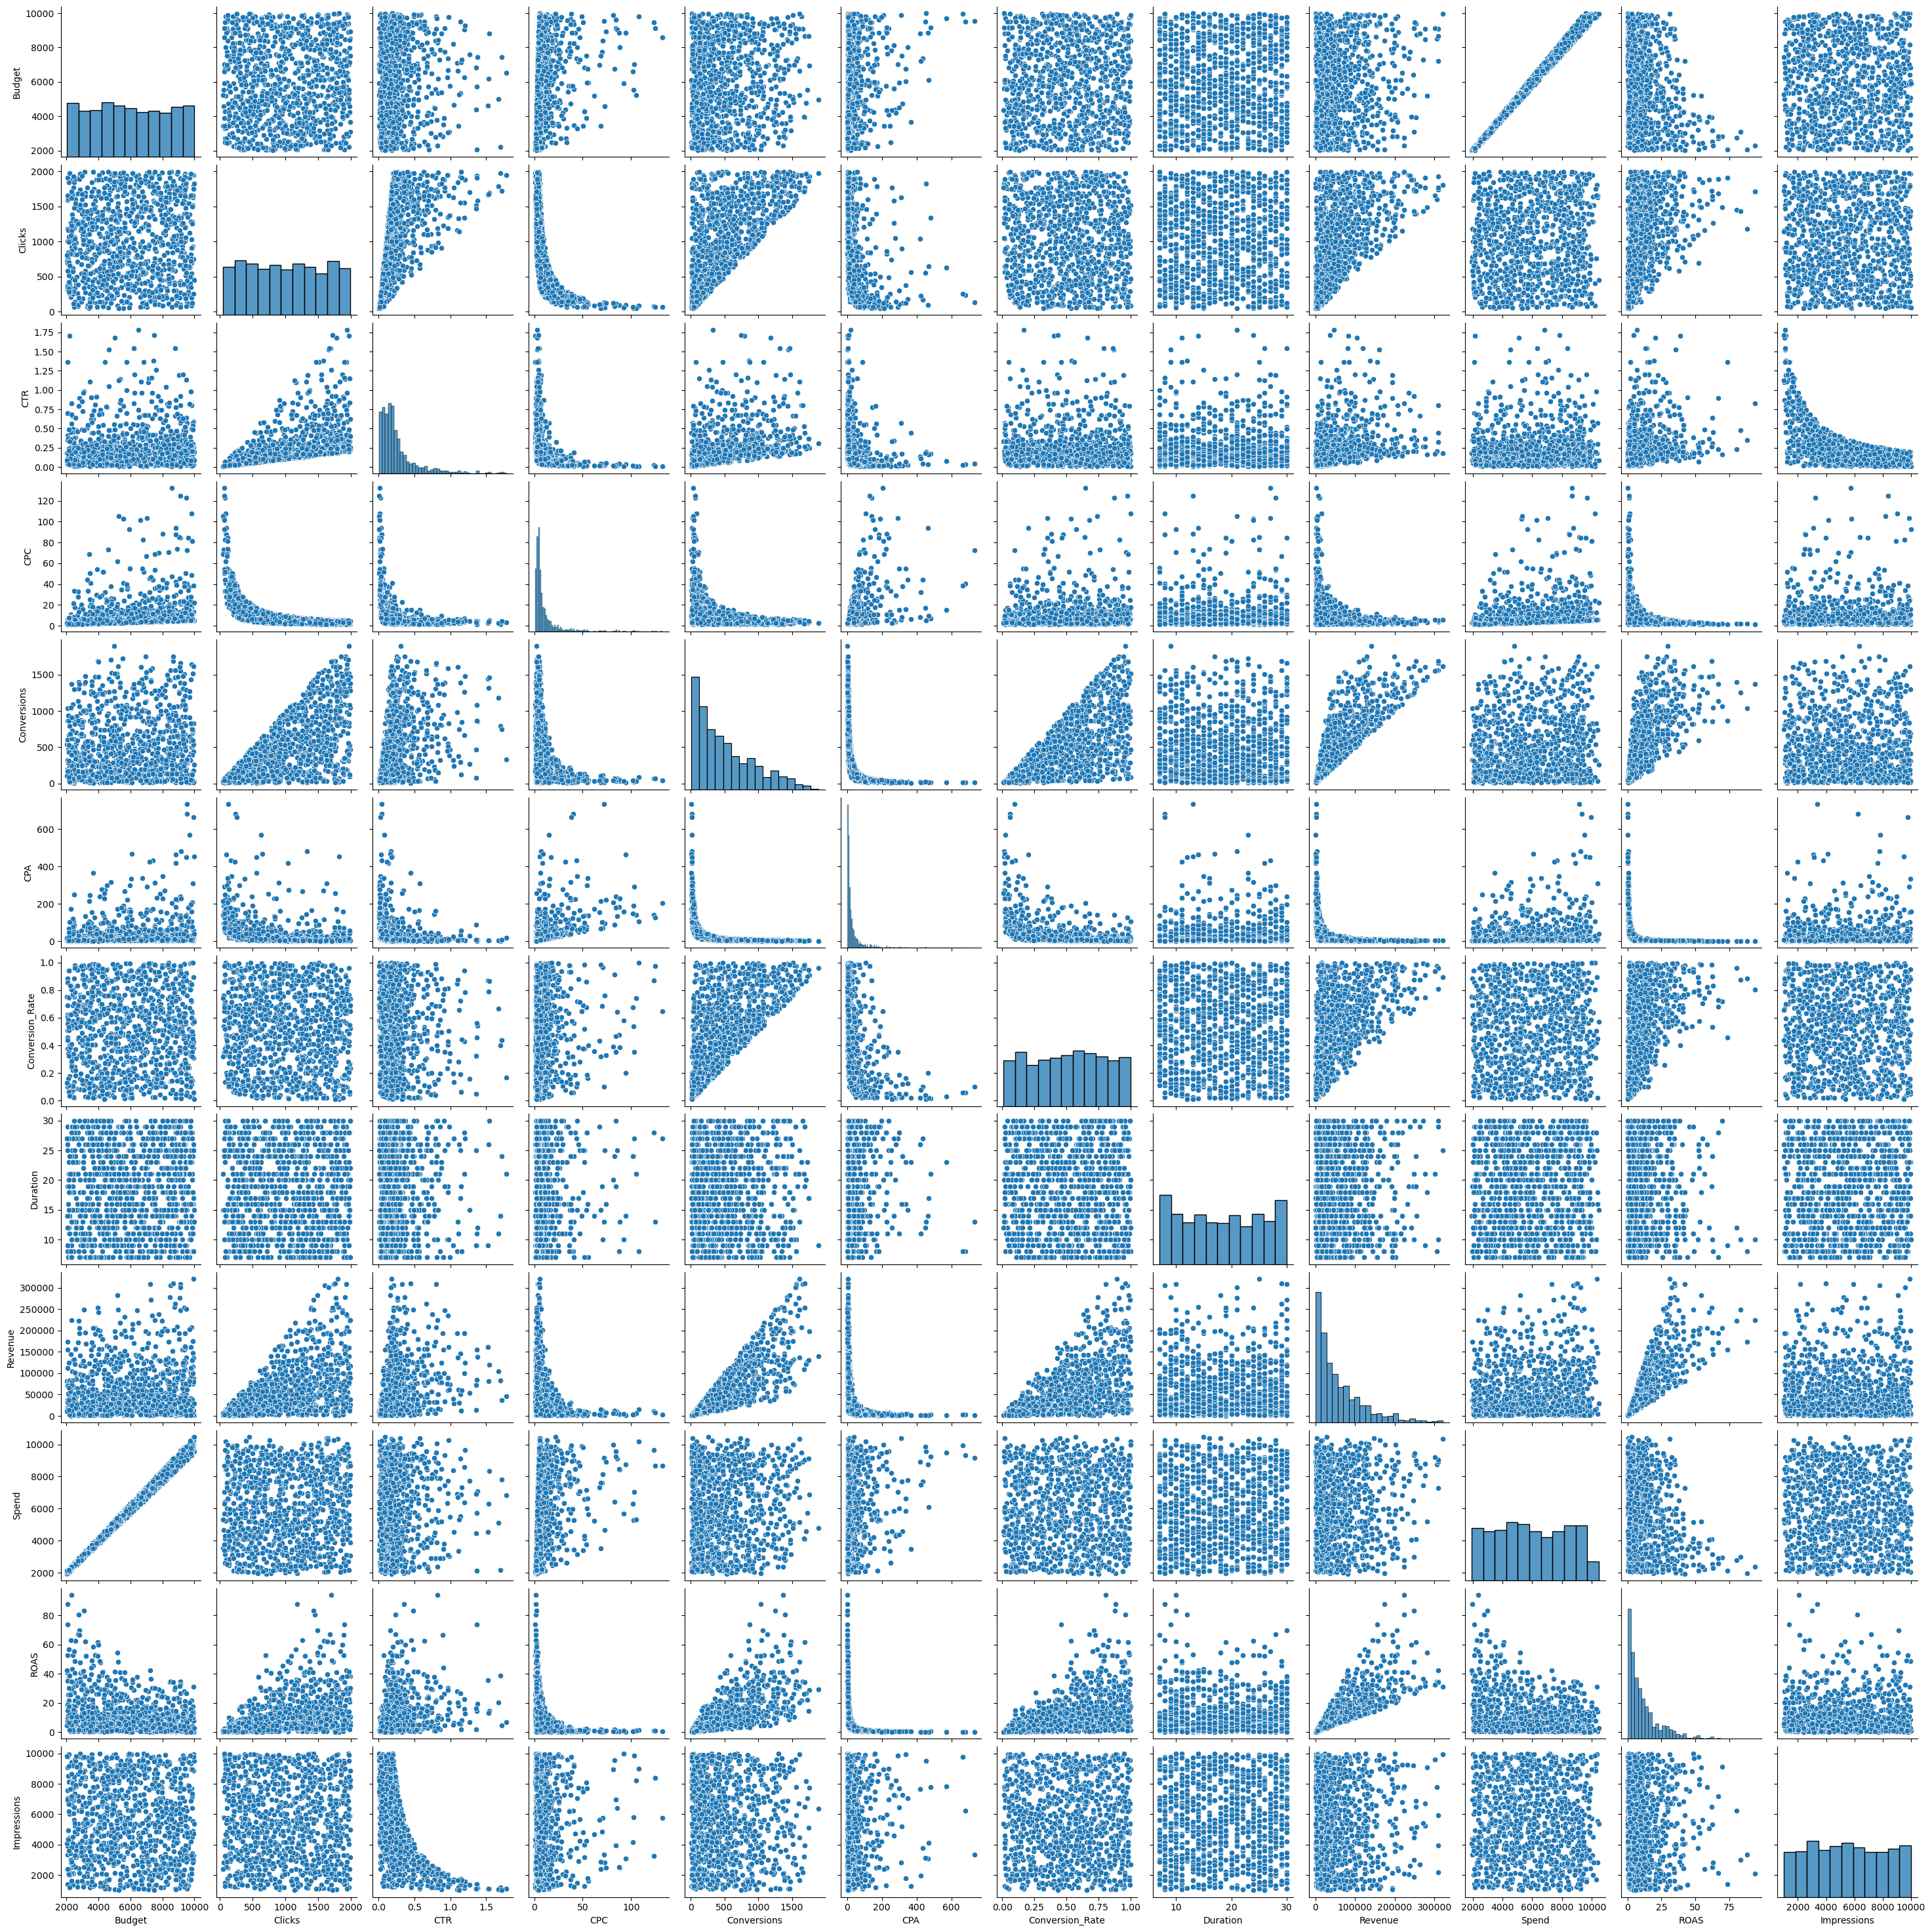

In [163]:
sns.pairplot(df[num_cols])
plt.show()


## Checking weighted CTR for better Understanding

In [137]:
df['weighted_ctr'] = df['CTR'] * np.log1p(df['Impressions'])

In [156]:
df.head()

,Campaign_ID,Budget,Clicks,CTR,CPC,Conversions,CPA,Conversion_Rate,Duration,Platform,...,ROAS,Date,Impressions,weighted_ctr,cep_score,day_name,day_num,month,month_name,quarter
0,C3578,6390,401,0.0461,15.94,174,36.72,0.4339,20,Instagram,...,4.31,2025-01-19,8698,0.418171,4.299666,Sunday,6,1,January,1
1,C6702,9870,1286,0.2860,7.67,821,12.02,0.6384,28,LinkedIn,...,12.72,2025-01-22,4496,2.405593,19.179082,Wednesday,2,1,January,1
2,C9725,7700,1684,0.2122,4.57,1060,7.26,0.6295,15,Instagram,...,25.45,2024-07-23,7935,1.905379,18.904649,Tuesday,1,7,July,3
3,C9472,8420,444,0.0961,18.96,308,27.34,0.6937,25,Google,...,2.82,2024-04-20,4620,0.810927,6.532238,Saturday,5,4,April,2
4,C7601,8470,1912,0.3652,4.43,1428,5.93,0.7469,9,Google,...,34.43,2024-08-07,5235,3.127322,26.425885,Wednesday,2,8,August,3


In [141]:
df['cep_score'] = df['Clicks'] / np.sqrt(df['Impressions'])

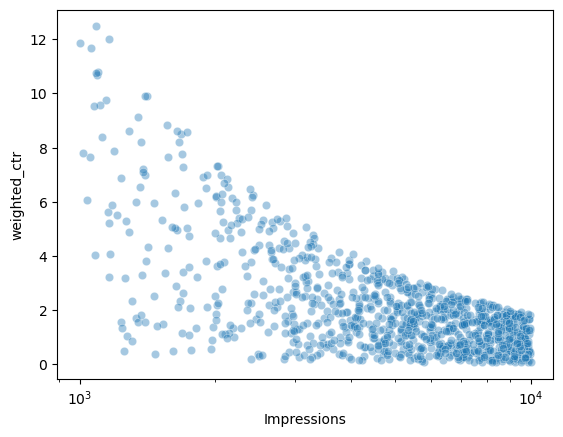

As the impressions Increases, CTR drops which is quite understandable as Higher impressions doesn't always mean higher CTR 


In [150]:
sns.scatterplot(
    data=df,
    x='Impressions',
    y='weighted_ctr',
    alpha=0.4
)
plt.xscale('log')
plt.show()
print("As the impressions Increases, CTR drops which is quite understandable as Higher impressions doesn't always mean higher CTR ")

#### Quick Summary
Impressions and Spend are almost perfectly related. As spend goes up, impressions go up in a very clean straight-line pattern. This is expected and confirms there is no data issue here.

CTR behaves very differently. It is high and unstable at low impressions but drops quickly as impressions increase. After a certain point, CTR stays low and does not recover, which shows a clear saturation effect.

Clicks increase with impressions and spend, but the growth is not proportional. At higher impressions, clicks grow slower, which explains why CTR falls when scale increases.

CPC has a strong inverse relationship with CTR. High CTR almost always comes with low CPC, and when CTR drops, CPC rises sharply. This makes CPC very sensitive to engagement quality.

Conversions are positively related to clicks and impressions, but with noticeable spread. This suggests conversion performance depends on more than just reach, such as audience quality or intent.

CPA shows a clear inverse pattern with conversions. When conversions are high, CPA stays low. When conversions are low, CPA increases rapidly, especially at low volumes.

ROAS improves with higher conversions and reasonable spend, but becomes unstable at low spend or low conversion counts. High ROAS at low volume appears noisy and unreliable.

So we can say:

Reach metrics like spend and impressions scale cleanly. Performance metrics like CTR, CPC, CPA, and ROAS are volume sensitive and unstable at low scale. Reliable decisions should be made in the mid to high impression range, not from extreme low volume points.

In [165]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///temp.db")
df.to_sql("campaign_data", engine, if_exists="replace", index=False)


1000

In [167]:
with open("campaign_data.sql", "w") as f:
    for line in engine.raw_connection().iterdump():
        f.write(f"{line}\n")


In [169]:
df.to_csv("campaign2.csv", index= False)